# AI Fairness Evaluation Assignment

## Importing Libraries

In [18]:
# Importing necessary libraries
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from skimage.metrics import structural_similarity as ssim
from skimage import exposure
from brisque import BRISQUE

Disclaimer:<br>
Steps 1-4A have been based on the following ChatGPT chat:<br>
[Source]()

## Step 1 - Pre-process Datasets

**Declaring paths to the datasets**

In [2]:
# Origingal dataset
dataset1Low = "data/dataset1/low"
dataset1High = "data/dataset1/high"
dataset2Input = "data/dataset2/input"
dataset2Target = "data/dataset2/target"

# Outputs
outputFolder = "outputs"
dataset1Processed = outputFolder + "/dataset1"
dataset2Processed = outputFolder + "/dataset2"
resized = outputFolder + "/resized"

**Getting image filenames**

In [3]:
dataset1Files = os.listdir(dataset1Low)
dataset2Files = os.listdir(dataset2Input)

dataset1Files = [f for f in dataset1Files if f.endswith(".png")]
dataset2Files = [f for f in dataset2Files if f.endswith(".png")]

# Checking if the code works
print("Dataset 1 images:", len(dataset1Files))
print("Dataset 2 images:", len(dataset2Files))

Dataset 1 images: 15
Dataset 2 images: 90


**Enhancement code**

In [4]:
# CLAHE
def applyCLAHE(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit = 2, tileGridSize = (8, 8))
    result = clahe.apply(gray)
    return cv2.cvtColor(result, cv2.COLOR_GRAY2BGR)

# Unsharp mask
def applyUnsharpMask(image):
    blurred = cv2.GaussianBlur(image, (0, 0), 1)
    result = cv2.addWeighted(image, 2.5, blurred, -1.5, 0)
    return result

# Box filter
def applyBoxFilter(image):
    return cv2.boxFilter(image, -1, (5, 5))

# Gaussian Smooth
def applyGaussianSmooth(image):
    return cv2.GaussianBlur(image, (5, 5), 1.5)

# Histogram Equalisation
def applyHistogramEqualisation(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    result = cv2.equalizeHist(gray)
    return cv2.cvtColor(result, cv2.COLOR_GRAY2BGR)

# Gamma correction
def applyGammaCorrection(image):
    gamma = 0.7
    imageNormalised = image / 255
    imageCorrected = np.power(imageNormalised, gamma)
    return np.uint8(imageCorrected * 255)

# Bilateral filter
def applyBilateralFilter(image):
    return cv2.bilateralFilter(image, 15, 75, 75)

# Denoise
def applyDenoise(image):
    return cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)

# Adaptive hist EQ
def applyAdaptiveHistEQ(image):
    imageRGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    result = exposure.equalize_adapthist(imageRGB / 255)
    result = np.uint8(result * 255)
    return cv2.cvtColor(result, cv2.COLOR_RGB2BGR)

# Saturation
def applySaturation(image):
    HSV = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    HSV[:, :, 1] = np.clip(HSV[:, :, 1] * 1.5, 0, 255)
    return cv2.cvtColor(HSV, cv2.COLOR_HSV2BGR)

# High pass filter
def applyHighPassFilter(image):
    blurred = cv2.GaussianBlur(image, (5, 5), 1.5)
    result = cv2.subtract(image, blurred)
    return result

**Choosing one method**

In [5]:
# This function can be changed if a different method of pre-processing is desired
def preprocessImage(image):
    result = applyCLAHE(image)
    return result

**Pre-processing datasets**

In [6]:
# Dataset 1
for filename in dataset1Files:
    imagePath = dataset1Low + "/" + filename
    image = cv2.imread(imagePath)

    processed = preprocessImage(image)

    savePath = outputFolder + "/dataset1/" + filename
    cv2.imwrite(savePath, processed)

print("Dataset 1 pre-processing complete.")

# Dataset 2
for filename in dataset2Files:
    imagePath = dataset2Input + "/" + filename
    image = cv2.imread(imagePath)

    processed = preprocessImage(image)

    savePath = outputFolder + "/dataset2/" + filename
    cv2.imwrite(savePath, processed)

print("Dataset 2 pre-processing complete.")

Dataset 1 pre-processing complete.
Dataset 2 pre-processing complete.


## Step 2 - Metric Testing

**Metric functions**

In [19]:
# PSNR
def calculatePSNR(original, compared):
    MSE = np.mean((original - compared) ** 2)

    if MSE == 0:
        return 100

    maxPixel = 255
    PSNR = 20 * np.log10(maxPixel / np.sqrt(MSE))

    return PSNR

# SSIM
def calculateSSIM(original, compared):
    originalGray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    comparedGray = cv2.cvtColor(compared, cv2.COLOR_BGR2GRAY)

    value = ssim(originalGray, comparedGray, data_range = 255)

    return value

# BRISQUE
def calculateBRISQUE(imagePath):
    try:
        image = cv2.imread(imagePath)

        if image is None:
            return np.nan

        if image.shape[0] < 64 or image.shape[1] < 64:
            return np.nan

        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        _BRISQUE = BRISQUE()
        score = _BRISQUE.score(image)

        return score

    except Exception as e:
        print("BRISQUE error:", e)
        return np.nan

# NIQE
def calculateNIQE(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    mean = np.mean(gray)
    std = np.std(gray)

    score = abs(mean - 127.5) + abs(std - 64)

    return score

**Testing metrics**

In [20]:
# Testing the metrics using the previously declared functions
filename = dataset1Files[0]

highImage = cv2.imread(dataset1High + "/" + filename)
lowImage = cv2.imread(dataset1Low + "/" + filename)

PSNRValue = calculatePSNR(highImage, lowImage)
SSIMValue = calculateSSIM(highImage, lowImage)
BRISQUEValue = calculateBRISQUE(dataset1Low + "/" + filename)
NIQEValue = calculateNIQE(lowImage)

print("PSNR:", PSNRValue)
print("SSIM:", SSIMValue)
print("BRISQUE:", BRISQUEValue)
print("NIQE:", NIQEValue)

PSNR: 27.789972533257817
SSIM: 0.24339526026144834
BRISQUE: 21.024596993221365
NIQE: 143.56711585615898


## Step 3 - Calculate Evaluation Metrics on Original Data

**Original data metrics**

In [21]:
# Dataset 1
resultsDataset1Original = []

for filename in dataset1Files:
    highPath = dataset1High + "/" + filename
    lowPath = dataset1Low + "/" + filename

    highImage = cv2.imread(highPath)
    lowImage = cv2.imread(lowPath)

    if highImage is None or lowImage is None:
        continue

    PSNRValue = calculatePSNR(highImage, lowImage)
    SSIMValue = calculateSSIM(highImage, lowImage)
    BRISQUEValue = calculateBRISQUE(lowPath)
    NIQEValue = calculateNIQE(lowImage)

    resultsDataset1Original.append(["dataset1", filename, "original", PSNRValue, SSIMValue, BRISQUEValue, NIQEValue])

dfDataset1Original = pd.DataFrame(resultsDataset1Original, columns = ["dataset", "filename", "type", "PSNR", "SSIM", "BRISQUE", "NIQE"])

display(dfDataset1Original.head())

# Dataset 2
resultsDataset2Original = []

for filename in dataset2Files:
    targetPath = dataset2Target + "/" + filename
    inputPath = dataset2Input + "/" + filename

    targetImage = cv2.imread(targetPath)
    inputImage = cv2.imread(inputPath)

    if targetImage is None or inputImage is None:
        continue

    PSNRValue = calculatePSNR(targetImage, inputImage)
    SSIMValue = calculateSSIM(targetImage, inputImage)
    BRISQUEValue = calculateBRISQUE(inputPath)
    NIQEValue = calculateNIQE(inputImage)

    resultsDataset2Original.append(["dataset2", filename, "original", PSNRValue, SSIMValue, BRISQUEValue, NIQEValue])

dfDataset2Original = pd.DataFrame(resultsDataset2Original, columns = ["dataset", "filename", "type", "PSNR", "SSIM", "BRISQUE", "NIQE"])

display(dfDataset2Original.head())

,dataset,filename,type,PSNR,SSIM,BRISQUE,NIQE
0,dataset1,1.png,original,27.789973,0.243395,21.024597,143.567116
1,dataset1,111.png,original,27.977366,0.193150,27.173536,161.444256
2,dataset1,146.png,original,28.539462,0.258655,-1.546362,154.398589
3,dataset1,179.png,original,27.797829,0.431618,0.192702,164.216985
4,dataset1,22.png,original,27.655770,0.188468,20.288842,159.177909


,dataset,filename,type,PSNR,SSIM,BRISQUE,NIQE
0,dataset2,uieb_10945.png,original,27.730635,0.775979,67.067772,70.011382
1,dataset2,uieb_112_img_.png,original,28.463049,0.743476,30.128054,54.578202
2,dataset2,uieb_117_img_.png,original,27.990357,0.740728,4.441320,41.042570
3,dataset2,uieb_120_img_.png,original,27.832871,0.583641,14.503885,42.685354
4,dataset2,uieb_12324.png,original,27.459798,0.473858,45.477838,105.030567


**Original data summary**

In [22]:
originalResults = pd.concat([dfDataset1Original, dfDataset2Original])

originalSummary = originalResults.groupby(["dataset", "type"])[["PSNR", "SSIM", "BRISQUE", "NIQE"]].mean()

display(originalSummary)

,,PSNR,SSIM,BRISQUE,NIQE
dataset,type,,,,
dataset1,original,27.959167,0.189775,18.003817,166.175521
dataset2,original,28.319352,0.818716,26.111517,52.366277


**Pre-processed data metrics**

In [23]:
# Dataset 1
resultsDataset1Processed = []

for filename in dataset1Files:
    highPath = dataset1High + "/" + filename
    processedPath = outputFolder + "/dataset1/" + filename

    highImage = cv2.imread(highPath)
    processedImage = cv2.imread(processedPath)

    if highImage is None or processedImage is None:
        continue

    PSNRValue = calculatePSNR(highImage, processedImage)
    SSIMValue = calculateSSIM(highImage, processedImage)
    BRISQUEValue = calculateBRISQUE(processedPath)
    NIQEValue = calculateNIQE(processedImage)

    resultsDataset1Processed.append(["dataset1", filename, "processed", PSNRValue, SSIMValue, BRISQUEValue, NIQEValue])

dfDataset1Processed = pd.DataFrame(resultsDataset1Processed, columns = ["dataset", "filename", "type", "PSNR", "SSIM", "BRISQUE", "NIQE"])

display(dfDataset1Processed.head())

# Dataset 2
resultsDataset2Processed = []

for filename in dataset2Files:
    targetPath = dataset2Target + "/" + filename
    processedPath = outputFolder + "/dataset2/" + filename

    targetImage = cv2.imread(targetPath)
    processedImage = cv2.imread(processedPath)

    if targetImage is None or processedImage is None:
        continue

    PSNRValue = calculatePSNR(targetImage, processedImage)
    SSIMValue = calculateSSIM(targetImage, processedImage)
    BRISQUEValue = calculateBRISQUE(processedPath)
    NIQEValue = calculateNIQE(processedImage)

    resultsDataset2Processed.append(["dataset2", filename, "processed", PSNRValue, SSIMValue, BRISQUEValue, NIQEValue])

dfDataset2Processed = pd.DataFrame(resultsDataset2Processed, columns = ["dataset", "filename", "type", "PSNR", "SSIM", "BRISQUE", "NIQE"])

display(dfDataset2Processed.head())

,dataset,filename,type,PSNR,SSIM,BRISQUE,NIQE
0,dataset1,1.png,processed,27.870293,0.518614,26.824507,112.769183
1,dataset1,111.png,processed,28.241116,0.405047,19.940780,130.317752
2,dataset1,146.png,processed,27.975768,0.504909,18.674314,122.571718
3,dataset1,179.png,processed,28.020684,0.780083,25.836098,129.509830
4,dataset1,22.png,processed,28.275208,0.437185,20.795436,125.959243


,dataset,filename,type,PSNR,SSIM,BRISQUE,NIQE
0,dataset2,uieb_10945.png,processed,27.639058,0.902865,46.165639,59.876542
1,dataset2,uieb_112_img_.png,processed,27.678618,0.913339,17.818571,43.803576
2,dataset2,uieb_117_img_.png,processed,28.041264,0.919902,7.809504,22.401478
3,dataset2,uieb_120_img_.png,processed,27.990302,0.830882,12.509628,36.666594
4,dataset2,uieb_12324.png,processed,27.815470,0.710098,26.917113,74.571706


**Original vs processed**

In [24]:
processedResults = pd.concat([dfDataset1Processed, dfDataset2Processed])

allResults = pd.concat([originalResults, processedResults])

summary = allResults.groupby(["dataset", "type"])[["PSNR", "SSIM", "BRISQUE", "NIQE"]].mean()

display(summary)

PSNR      SSIM    BRISQUE        NIQE
dataset  type                                                 
dataset1 original   27.959167  0.189775  18.003817  166.175521
         processed  27.883177  0.431209  22.474880  137.391746
dataset2 original   28.319352  0.818716  26.111517   52.366277
         processed  28.047101  0.897108  25.539931   34.345682

**Interpretation (Dataset 1):**
- pre-processing improved SSIM (0.19 -> 0.431) - processed images became more structurally similar to the reference images
- NIQE also improved (166.176 -> 137.392) - processed images looked more natural (without looking at references)
- PSNR slighlty decreased (27.959 -> 27.883) - possible introduction of pixel-level changes pr artefacts
- BRISQUE became worse (18.004 -> 22.475) - same as for PSNR<br>

Overall, pre-processing was useful, as it improved SSIM & NIQE, but there was a trade-off between contrast enhancement and pixel-level accuracy

**Interpretation (Dataset 2):**
- SSIM increased (0,819 -> 0.897) - the processed images became more structurally similar to the target images
- NIQE improved strongly (52.366 -> 34.346) - judged more natural without references
- BRISQUE improved slightly (26.112 -> 25.54) - slightly more pixel-perfect
- PSNR decreased (28.319 -> 28.047) - processed images were slightly less pixel-perfect<br>

Overall, Dataset 2 responded better to pre-processing than Dataset 1. SSIM, BRISQUE, and NIQE all improved, while only PSNR decreased slightly.

## Step 4 - Calculate Evaluation Metrics on Resized Data

### Part A

**Resizing and calculating metrics**

In [25]:
# Dataset 1
resizePercentages = [25, 50, 75, 100]

resultsDataset1Resized = []

for filename in dataset1Files:
    highPath = dataset1High + "/" + filename
    lowPath = dataset1Low + "/" + filename

    highImage = cv2.imread(highPath)
    lowImage = cv2.imread(lowPath)

    if highImage is None or lowImage is None:
        continue

    for percent in resizePercentages:
        scale = percent / 100

        newWidth = int(lowImage.shape[1] * scale)
        newHeight = int(lowImage.shape[0] * scale)

        lowResized = cv2.resize(lowImage, (newWidth, newHeight))
        highResized = cv2.resize(highImage, (newWidth, newHeight))

        savePath = outputFolder + "/resized/dataset1_" + str(percent) + "_" + filename
        cv2.imwrite(savePath, lowResized)

        PSNRValue = calculatePSNR(highResized, lowResized)
        SSIMValue = calculateSSIM(highResized, lowResized)
        BRISQUEValue = calculateBRISQUE(savePath)
        NIQEValue = calculateNIQE(lowResized)

        resultsDataset1Resized.append(["dataset1", filename, percent, PSNRValue, SSIMValue, BRISQUEValue, NIQEValue])

dfDataset1Resized = pd.DataFrame(resultsDataset1Resized, columns = ["dataset", "filename", "resize_percent", "PSNR", "SSIM", "BRISQUE", "NIQE"])

display(dfDataset1Resized.head())

# Dataset 2
resultsDataset2Resized = []

for filename in dataset2Files:
    targetPath = dataset2Target + "/" + filename
    inputPath = dataset2Input + "/" + filename

    targetImage = cv2.imread(targetPath)
    inputImage = cv2.imread(inputPath)

    if targetImage is None or inputImage is None:
        continue

    for percent in resizePercentages:
        scale = percent / 100

        newWidth = int(inputImage.shape[1] * scale)
        newHeight = int(inputImage.shape[0] * scale)

        inputResized = cv2.resize(inputImage, (newWidth, newHeight))
        targetResized = cv2.resize(targetImage, (newWidth, newHeight))

        savePath = outputFolder + "/resized/dataset2_" + str(percent) + "_" + filename
        cv2.imwrite(savePath, inputResized)

        PSNRValue = calculatePSNR(targetResized, inputResized)
        SSIMValue = calculateSSIM(targetResized, inputResized)
        BRISQUEValue = calculateBRISQUE(savePath)
        NIQEValue = calculateNIQE(inputResized)

        resultsDataset2Resized.append(["dataset2", filename, percent, PSNRValue, SSIMValue, BRISQUEValue, NIQEValue])

dfDataset2Resized = pd.DataFrame(resultsDataset2Resized, columns = ["dataset", "filename", "resize_percent", "PSNR", "SSIM", "BRISQUE", "NIQE"])

display(dfDataset2Resized.head())

,dataset,filename,resize_percent,PSNR,SSIM,BRISQUE,NIQE
0,dataset1,1.png,25,27.773140,0.217116,27.312654,143.534611
1,dataset1,1.png,50,27.798332,0.234277,25.302560,143.563038
2,dataset1,1.png,75,27.795689,0.240350,26.945467,143.739575
3,dataset1,1.png,100,27.789973,0.243395,21.024597,143.567116
4,dataset1,111.png,25,27.962107,0.160418,33.271306,161.429293


,dataset,filename,resize_percent,PSNR,SSIM,BRISQUE,NIQE
0,dataset2,uieb_10945.png,25,27.724656,0.685343,29.635636,69.989819
1,dataset2,uieb_10945.png,50,27.733246,0.729871,41.633645,70.007943
2,dataset2,uieb_10945.png,75,27.731058,0.759586,57.492333,70.050931
3,dataset2,uieb_10945.png,100,27.730635,0.775979,67.067772,70.011382
4,dataset2,uieb_112_img_.png,25,28.477615,0.684851,14.686211,54.503525


**Interpretation (Dataset 1):**
- PSNR increased slightly as image size increased (27.944 @ 25& -> 27.959 @ 100%) - resizing wasn't useful
- SSIM increased (0.166 @ 25% -> 0.19 @ 100%) - resizing removed fine details
- BRISQUE had the best result @ 100% (18.004) - the original full-size image had the best quality though
- NIQE was in a similar situation - differences are small, but the full-size image still performed best<br>

Overall, the best resize level was 100%. Reducing the image size generally reduced structural quality and did not improve the no-reference quality scores.

**Interpretation (Dataset 2):**
- PSNR was almost unchanged throughout the process - resizing had very little effect on pixel-level error
- SSIM increased steadily (0.799 @ 25% -> 0.819 @ 100%) - larger images preserved more structure and detail
- for BRISQUE the best results was @ 50% (16.742), whilst the full-size image had the worst BRISQUE (26.112) - moderate resizing may have removed some noise or artefacts
- NIQUE had the best result @ 100% (52.366) - the full-size image looked more natural according to this metric<br>

Overall, Dataset 2 shows a trade-off. 100% was best for SSIM and NIQE, while 50% was best for PSNR and BRISQUE. This means that if structural accuracy is most important, 100% should be used. But if speed and BRISQUE quality are more important, 50% may be acceptable.

**Summary table**

In [26]:
# Summary table
resizedResults = pd.concat([dfDataset1Resized, dfDataset2Resized])

resizedSummary = resizedResults.groupby(["dataset", "resize_percent"])[["PSNR", "SSIM", "BRISQUE", "NIQE"]].mean()

display(resizedSummary)

PSNR      SSIM    BRISQUE        NIQE
dataset  resize_percent                                            
dataset1 25              27.943916  0.166258  23.042730  166.308805
         50              27.945716  0.183539  23.670747  166.310962
         75              27.949801  0.188257  23.491719  166.450687
         100             27.959167  0.189775  18.003817  166.175521
dataset2 25              28.323317  0.799220  17.401178   52.768732
         50              28.324566  0.809658  16.742212   52.778508
         75              28.322230  0.816594  21.497076   52.726936
         100             28.319352  0.818716  26.111517   52.366277

**Interpretation:**<br>
- Dataset 1 had low SSIM overall - low-quality images were different from high-quality ones
- Dataset 2 had higher SSIM values - input & target images were already more similar
- In both datasets SSIM increased - higher resolution preserves structure better
- In Dataset 1, BRISQUE was best at 100%. In Dataset 2, BRISQUE was best at 50%<br>

Overall: for time sensitive applications (CCTV, autonomous system, etc.) -> resize to 50% (reduced processing time & keeping good enough quality). For detailed-image application (medical imaging, object detection, etc.) -> use 100% (keeping more structural information).

**Saving results**

In [27]:
# Saving all the results to .csv files
originalResults.to_csv(outputFolder + "/originalResults.csv", index = False)
processedResults.to_csv(outputFolder + "/processedResults.csv", index = False)
resizedResults.to_csv(outputFolder + "/resizedResults.csv", index = False)

summary.to_csv(outputFolder + "/summaryOriginalVSProcessed.csv")
resizedSummary.to_csv(outputFolder + "/summaryResized.csv")

print("CSV files saved.")

CSV files saved.


**Plotting**

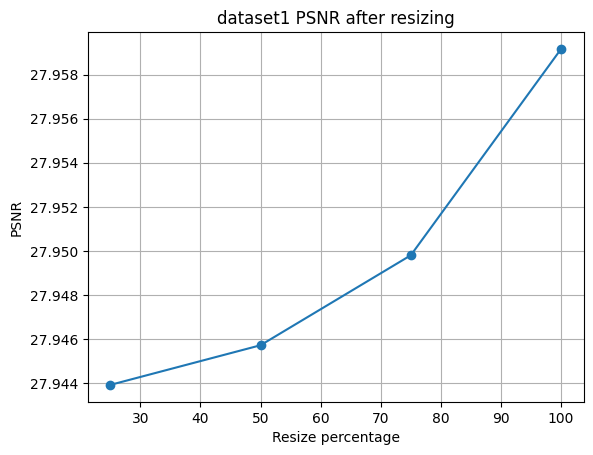

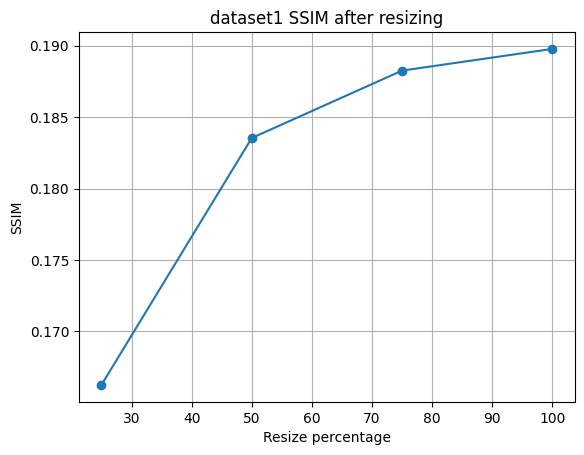

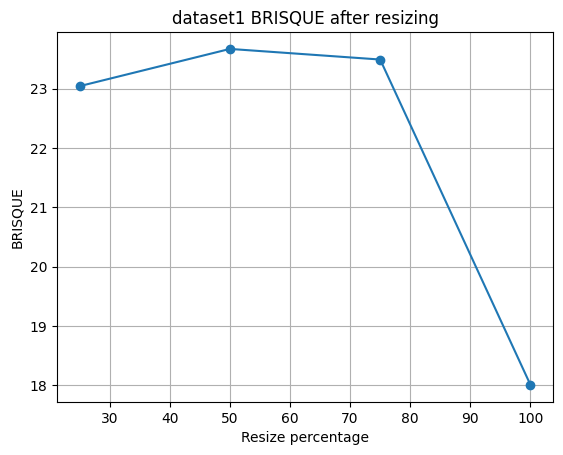

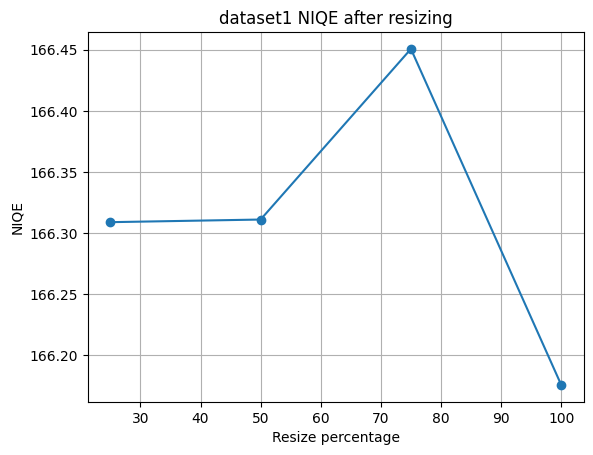

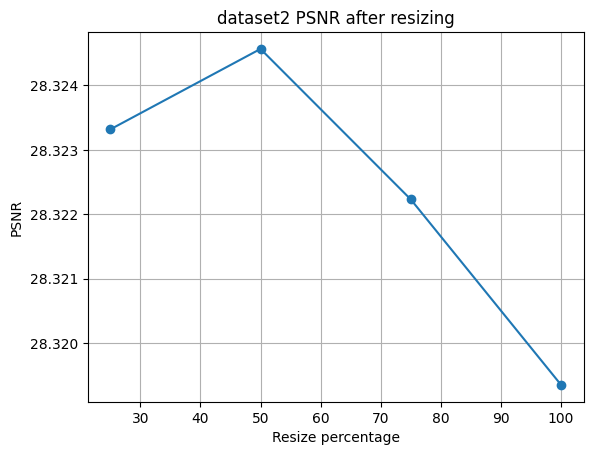

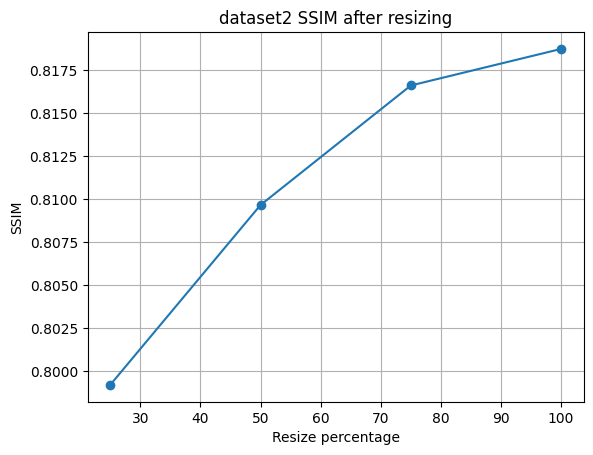

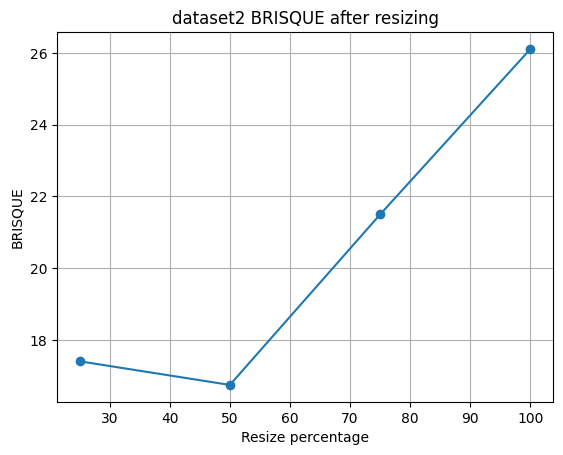

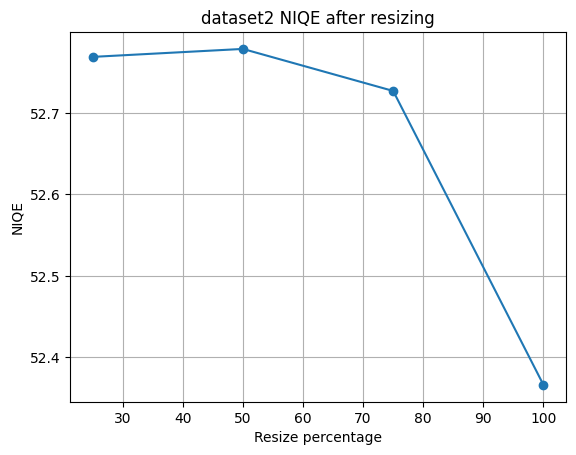

In [28]:
# Plotting the results
resizedSummaryReset = resizedSummary.reset_index()

for dataset_name in ["dataset1", "dataset2"]:
    data = resizedSummaryReset[resizedSummaryReset["dataset"] == dataset_name]

    plt.figure()
    plt.plot(data["resize_percent"], data["PSNR"], marker = "o")
    plt.title(dataset_name + " PSNR after resizing")
    plt.xlabel("Resize percentage")
    plt.ylabel("PSNR")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(data["resize_percent"], data["SSIM"], marker = "o")
    plt.title(dataset_name + " SSIM after resizing")
    plt.xlabel("Resize percentage")
    plt.ylabel("SSIM")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(data["resize_percent"], data["BRISQUE"], marker = "o")
    plt.title(dataset_name + " BRISQUE after resizing")
    plt.xlabel("Resize percentage")
    plt.ylabel("BRISQUE")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(data["resize_percent"], data["NIQE"], marker = "o")
    plt.title(dataset_name + " NIQE after resizing")
    plt.xlabel("Resize percentage")
    plt.ylabel("NIQE")
    plt.grid()
    plt.show()

### Part B

Matthew's part